In [4]:
import pandas as pd
from tqdm import tqdm

# Define the file path
file_path = '../..//datasets_raw/tpc-ds/parameter_sweep_1.log'

# Initialize an empty DataFrame
df = pd.DataFrame(columns=['Line', 'Type'])

# Open the file for reading
with open(file_path, 'r') as file:
    # Iterate through each line in the file
    for line in tqdm(file):
        # Check if the line contains any of the desired strings
        d = {'Line': line.strip()}
        if "statement: SET" in line:
            d['Type'] = 1
            df.loc[len(df)] = d
        elif "-- Filename:" in line:
            d['Type'] = 2
            df.loc[len(df)] = d
        elif "duration:" in line and len(df) >0 and df.loc[(len(df)-1)]['Type'] == 2:
            d['Type'] = 3
            df.loc[len(df)] = d
            


0it [00:00, ?it/s]

676864it [00:23, 28605.04it/s]


In [10]:
df.head()

,Line,Type
0,2023-11-06 16:34:40.811 EST [ 65495bf0.179a 3/...,1
1,2023-11-06 16:34:40.812 EST [ 65495bf0.179a 3/...,1
2,2023-11-06 16:34:40.812 EST [ 65495bf0.179a 3/...,1
3,2023-11-06 16:34:40.812 EST [ 65495bf0.179a 3/...,1
4,2023-11-06 16:34:40.813 EST [ 65495bf0.179a 3/...,1


In [106]:
df['Parameter'] = df.apply(lambda x: x['Line'].split(' ')[12] if x['Type'] ==1 else None, axis=1)
df['Value'] = df.apply(lambda x: int(x['Line'].split(' ')[14][:-1]) if x['Type'] ==1 else None, axis=1)
df['Query'] = df.apply(lambda x: int(x['Line'].split(' ')[-1][5:8]) if x['Type'] ==2 else None, axis=1)
df['Runtime'] = df.apply(lambda x: float(x['Line'].split(' ')[-2]) if x['Type'] ==3 else None, axis=1)
df['Query'] = df['Query'].ffill()
for parameter in df['Parameter'].dropna().unique():
    df[parameter] = df.apply(lambda x: x['Value'] if x['Parameter'] == parameter else None, axis=1).ffill()
df['TransactionID'] = df['Line'].apply(lambda x: x.split(' ')[5])
df2 = df[df['Type'] == 3].drop(columns=['Line', 'Type', 'Parameter', 'Value']).reset_index(drop=True)
col_list = list(df2.columns[2:]) + (list(df2.columns[:2]))
col_list[-3:-1] = ['Query', 'TransactionID']
df2 = df2[col_list]
df2 = df2.groupby(list(df2.columns[:-3])).apply(lambda x: x.sort_values(by='Runtime', ascending=False)).reset_index(drop=True)
df2["Rank"] = df2.apply(lambda x: (x.name % 190) + 1, axis=1)


In [107]:
df2.head()

,work_mem,max_parallel_workers,effective_cache_size,maintenance_work_mem,random_page_cost,seq_page_cost,Query,TransactionID,Runtime,Rank
0,128.0,1.0,262144.0,32768.0,4.0,1.0,35.0,3/2529,3549887.350,1
1,128.0,1.0,262144.0,32768.0,4.0,1.0,35.0,3/2631,3509839.520,2
2,128.0,1.0,262144.0,32768.0,4.0,1.0,95.0,3/2470,555744.251,3
3,128.0,1.0,262144.0,32768.0,4.0,1.0,95.0,3/2572,555644.746,4
4,128.0,1.0,262144.0,32768.0,4.0,1.0,6.0,3/2492,121928.094,5


In [108]:
df2.tail()

,work_mem,max_parallel_workers,effective_cache_size,maintenance_work_mem,random_page_cost,seq_page_cost,Query,TransactionID,Runtime,Rank
12155,256.0,2.0,524288.0,65536.0,1000.0,1000.0,3.0,3/15502,462.098,186
12156,256.0,2.0,524288.0,65536.0,1000.0,1000.0,37.0,3/15479,292.796,187
12157,256.0,2.0,524288.0,65536.0,1000.0,1000.0,37.0,3/15377,287.812,188
12158,256.0,2.0,524288.0,65536.0,1000.0,1000.0,82.0,3/15459,285.473,189
12159,256.0,2.0,524288.0,65536.0,1000.0,1000.0,82.0,3/15357,284.295,190


In [105]:
df3 = df2.groupby(list(df2.columns[:-2]), as_index=False).agg({'TransactionID': list, 'Runtime': 'mean'})
df3 = df3[col_list]
df3 = df3.groupby(list(df3.columns[:-3])).apply(lambda x: x.sort_values(by='Runtime', ascending=False)).reset_index(drop=True)
df3

,work_mem,max_parallel_workers,effective_cache_size,maintenance_work_mem,random_page_cost,seq_page_cost,Query,TransactionID,Runtime
0,128.0,1.0,262144.0,32768.0,4.0,1.0,35.0,"[3/2529, 3/2631]",3.529863e+06
1,128.0,1.0,262144.0,32768.0,4.0,1.0,95.0,"[3/2470, 3/2572]",5.556945e+05
2,128.0,1.0,262144.0,32768.0,4.0,1.0,6.0,"[3/2492, 3/2594]",1.218820e+05
3,128.0,1.0,262144.0,32768.0,4.0,1.0,14.0,"[3/2603, 3/2501]",3.959052e+04
4,128.0,1.0,262144.0,32768.0,4.0,1.0,23.0,"[3/2663, 3/2561]",2.743548e+04
...,...,...,...,...,...,...,...,...,...
6075,256.0,2.0,524288.0,65536.0,1000.0,1000.0,91.0,"[3/15429, 3/15327]",6.251360e+02
6076,256.0,2.0,524288.0,65536.0,1000.0,1000.0,93.0,"[3/15374, 3/15476]",5.577555e+02
6077,256.0,2.0,524288.0,65536.0,1000.0,1000.0,3.0,"[3/15400, 3/15502]",4.644640e+02
6078,256.0,2.0,524288.0,65536.0,1000.0,1000.0,37.0,"[3/15479, 3/15377]",2.903040e+02


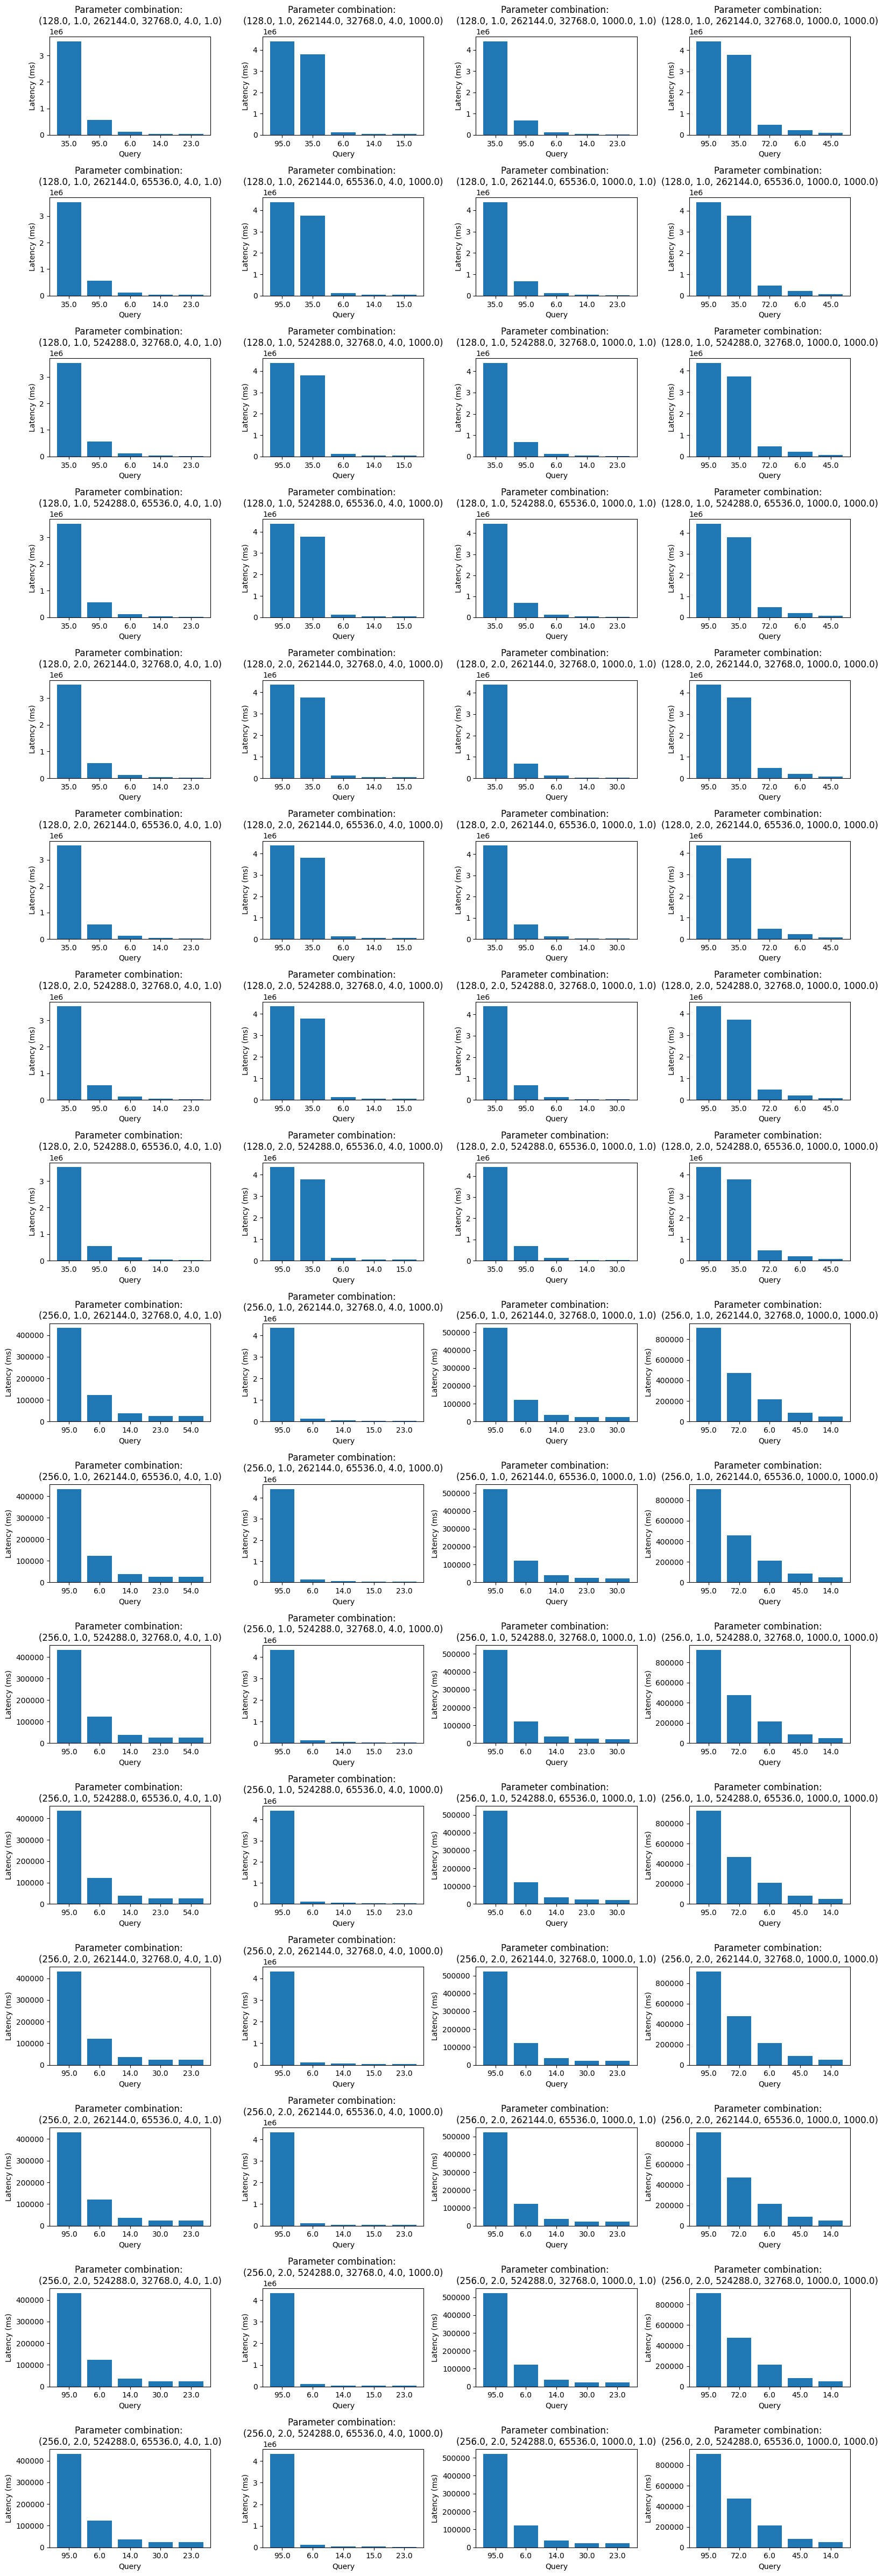

In [101]:
import matplotlib.pyplot as plt
df3head = df3.groupby(list(df3.columns[:6])).head(5)
grouped = df3head.groupby(list(df3.columns[:6]))


# Create a subplot grid with 16 rows and 4 columns
fig, axs = plt.subplots(16, 4, figsize=(16, 48))

# Flatten the axs array for easy iteration
axs = axs.flatten()

# Iterate through each group and create a bar plot
for i, (name, group) in enumerate(grouped):
    ax = axs[i]
    ax.bar(range(5), group['Runtime'])
    ax.set_xlabel('Query')
    ax.set_ylabel('Latency (ms)')
    ax.set_title(f'Parameter combination: \n{name}')

    # Set x-axis labels as categorical
    ax.set_xticks(range(5))
    ax.set_xticklabels(group['Query'])


# Adjust subplot spacing
plt.tight_layout()

# Show the subplots
plt.show()

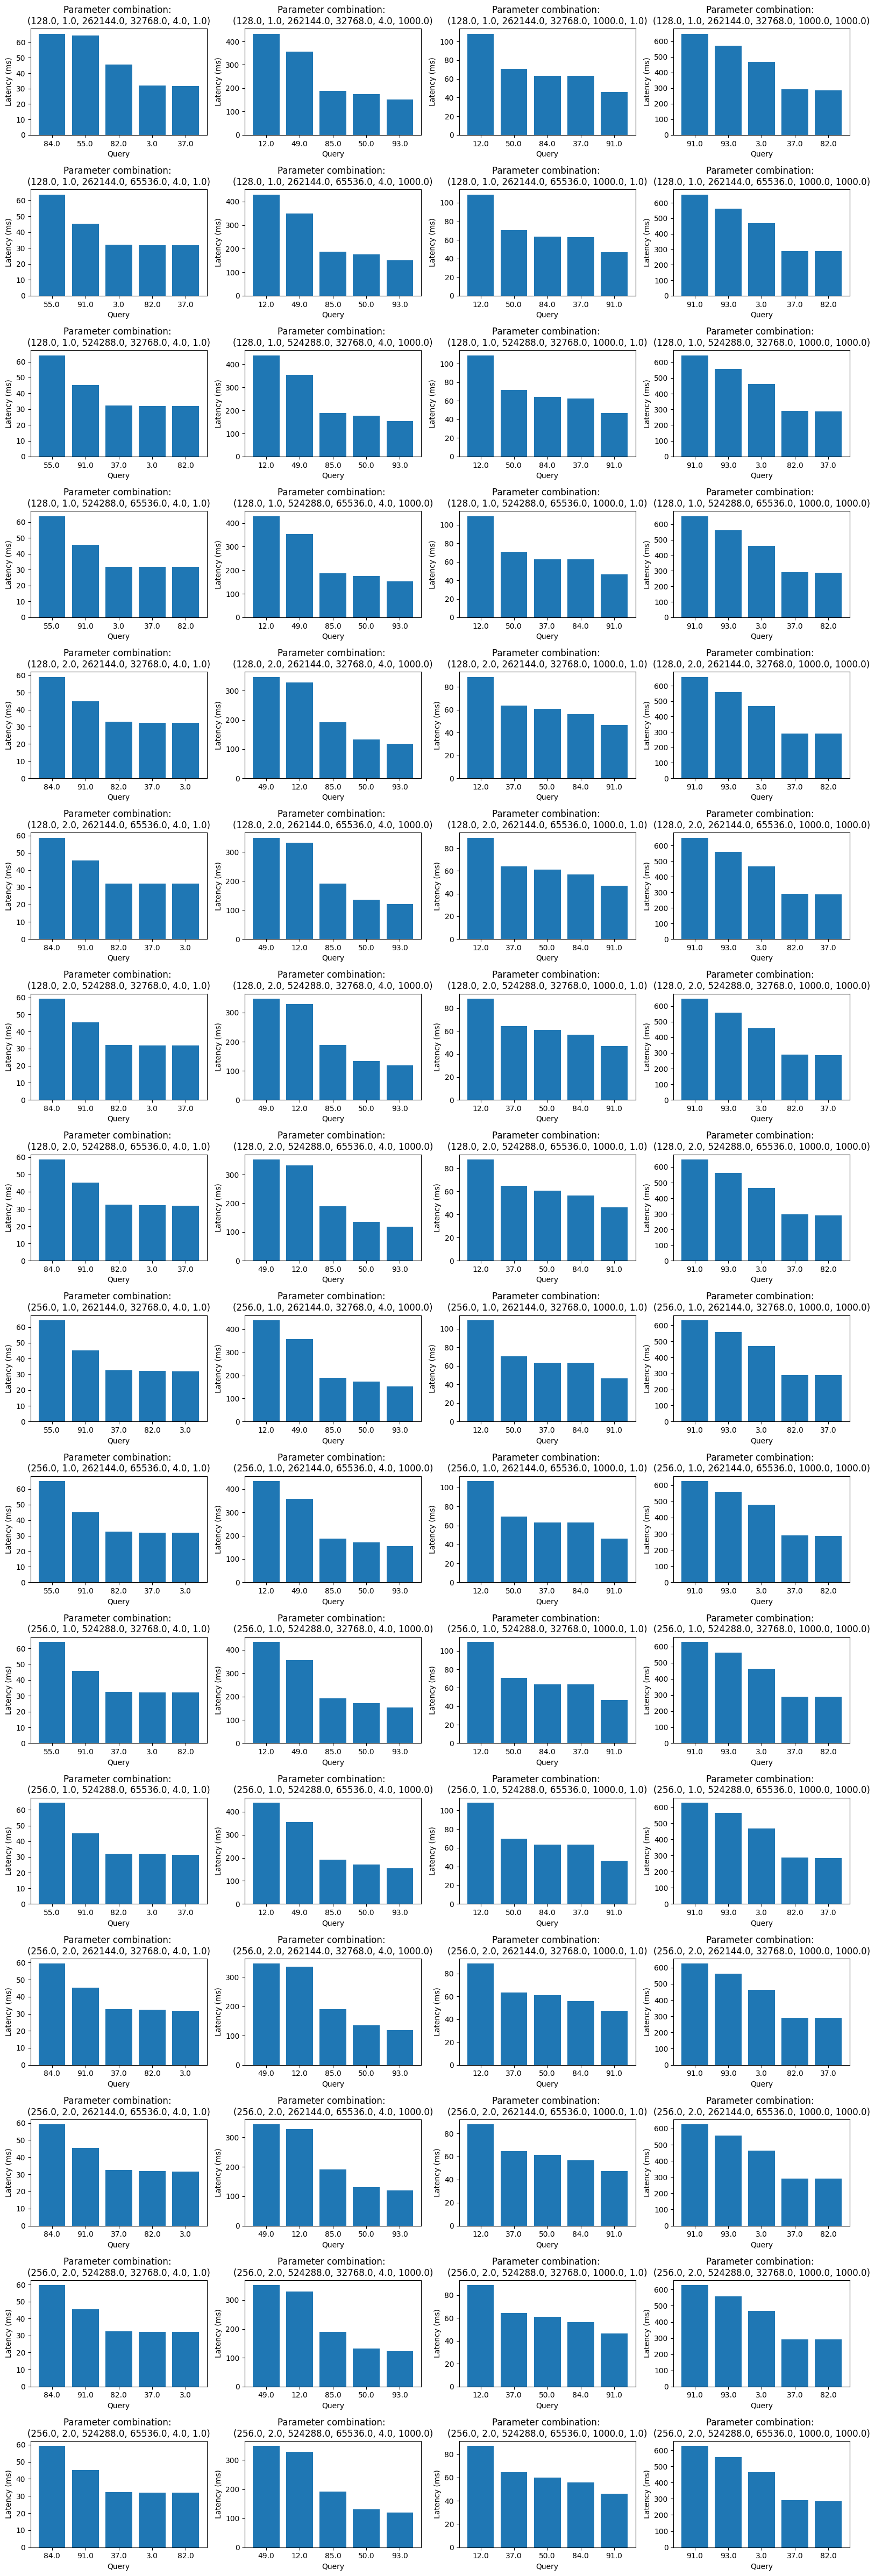

In [102]:
import matplotlib.pyplot as plt
df3tail = df3.groupby(list(df3.columns[:6])).tail(5)
grouped = df3tail.groupby(list(df3.columns[:6]))


# Create a subplot grid with 16 rows and 4 columns
fig, axs = plt.subplots(16, 4, figsize=(16, 48))

# Flatten the axs array for easy iteration
axs = axs.flatten()

# Iterate through each group and create a bar plot
for i, (name, group) in enumerate(grouped):
    ax = axs[i]
    ax.bar(range(5), group['Runtime'])
    ax.set_xlabel('Query')
    ax.set_ylabel('Latency (ms)')
    ax.set_title(f'Parameter combination: \n{name}')

    # Set x-axis labels as categorical
    ax.set_xticks(range(5))
    ax.set_xticklabels(group['Query'])


# Adjust subplot spacing
plt.tight_layout()

# Show the subplots
plt.show()

In [114]:
import pickle
with open("tpc-ds-parameter-sweep-1-candidate-causes-124eae94_11+mean.pkl", "rb") as f:
    cand_df = pickle.load(f)

In [116]:
def extract_transaction_id(x):
    toks = x.split('=')
    if len(toks) == 1: 
        return None
    elif toks[-1].startswith('3/'):
        return toks[-1]
    else:
        return None
cand_df['TransactionID'] = cand_df['Candidate'].apply(extract_transaction_id)
cand_df = cand_df.merge(df2, on=['TransactionID'], how='left')
cand_df

,Candidate,ATE,P-value,Standard Error,Tag,TransactionID,Rank_x,work_mem,max_parallel_workers,effective_cache_size,maintenance_work_mem,random_page_cost,seq_page_cost,Query,Runtime,Rank_y
0,d5d5269c_14+mean,-123.849521,4.155214e-28,[8.673335061474381],work_mem,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Timestamp+earliest,-0.036866,9.323056e-17,[0.003832935377784925],Timestamp,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,58a16510_14+mean,11.191018,1.122839e-11,[1.4965085146111794],seq_page_cost,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5eee73d8_4+latest=3/4413,13781.552561,1.760139e-01,[10127.723760195735],5eee73d8_4,3/4413,178.0,128.0,1.0,524288.0,32768.0,4.0,1000.0,91.0,584.778,178.0
4,54b16c94_4+latest=3/4463,13781.552561,1.760139e-01,[10127.723760195735],54b16c94_4,3/4463,140.0,128.0,1.0,524288.0,32768.0,4.0,1000.0,37.0,1672.346,140.0
5,386d0bfe_4+latest=3/6912,13727.526741,1.777267e-01,[10128.306067910422],386d0bfe_4,3/6912,76.0,128.0,2.0,262144.0,65536.0,4.0,1000.0,36.0,2950.417,76.0
6,3b04769e_4+latest=3/6910,13727.526741,1.777267e-01,[10128.306067910422],3b04769e_4,3/6910,149.0,128.0,2.0,262144.0,65536.0,4.0,1000.0,42.0,1155.954,149.0
7,23c8b539_4+latest=3/6913,13727.526741,1.777267e-01,[10128.306067910422],23c8b539_4,3/6913,58.0,128.0,2.0,262144.0,65536.0,4.0,1000.0,38.0,4424.108,58.0
8,7bf98e90_13+latest=0;13;14.160,-12673.643407,2.136291e-01,[10139.20150917087],time,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,11ca8219_4+latest=3/10008,-12553.909155,2.180137e-01,[10140.38363556537],11ca8219_4,3/10008,161.0,256.0,1.0,262144.0,65536.0,4.0,1.0,61.0,160.859,161.0
